# 01 — Exploratory Data Analysis
**Dataset:** European Credit Card Fraud (ULB), 284,807 transactions over 2 days (Sept 2013), 492 frauds (0.172%).

**Phase 1 deliverable** — this notebook audits the data (missing values, duplicates, class balance) and explores the patterns that motivate the dissertation's two core challenges: **class imbalance** and **concept drift**. Findings feed Chapter 3 (Methodology) and Chapter 5 (Results).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from fraud import config, data

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)

Matplotlib is building the font cache; this may take a moment.


## 1. Load and audit

In [2]:
df_raw = data.load_raw()
print(f"Shape: {df_raw.shape}")
df_raw.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# Missing values and duplicates
n_missing = df_raw.isna().sum().sum()
n_dup = df_raw.duplicated().sum()
print(f"Missing values: {n_missing}")
print(f"Exact duplicate rows: {n_dup}")

df = data.clean(df_raw)
print(f"After cleaning: {df.shape} ({len(df_raw) - len(df)} duplicates removed)")

Missing values: 0
Exact duplicate rows: 1081


After cleaning: (283726, 31) (1081 duplicates removed)


## 2. Class imbalance — the first core challenge

Legitimate: 283,253
Fraud:      473
Fraud rate: 0.1667%  (roughly 1 fraud per 599 transactions)


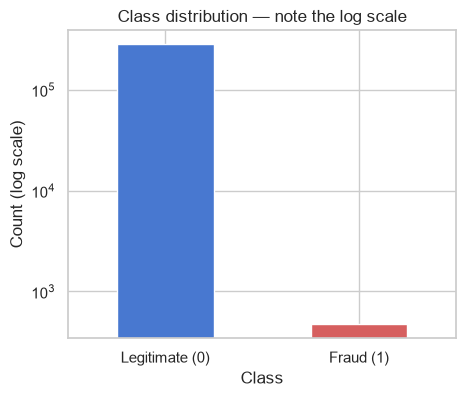

In [4]:
counts = df["Class"].value_counts()
fraud_rate = df["Class"].mean()
print(f"Legitimate: {counts[0]:,}")
print(f"Fraud:      {counts[1]:,}")
print(f"Fraud rate: {fraud_rate:.4%}  (roughly 1 fraud per {int(1/fraud_rate):,} transactions)")

fig, ax = plt.subplots(figsize=(5, 4))
counts.plot.bar(ax=ax, color=["#4878d0", "#d65f5f"])
ax.set_yscale("log")
ax.set_xticklabels(["Legitimate (0)", "Fraud (1)"], rotation=0)
ax.set_ylabel("Count (log scale)")
ax.set_title("Class distribution — note the log scale")
config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(config.FIGURES_DIR / "eda_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

A classifier that predicts "legitimate" for **every** transaction achieves ~99.83% accuracy while catching zero fraud. This is why accuracy (and to a lesser degree ROC-AUC) is misleading here, and why this project reports precision, recall, F1, **PR-AUC** and **MCC** instead (Baisholan et al., 2025).

## 3. Transaction amount by class

/var/folders/th/rq6vvtvj3bv899gsrrfrxxyc0000gn/T/ipykernel_40170/85087357.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(["Legitimate", "Fraud"])


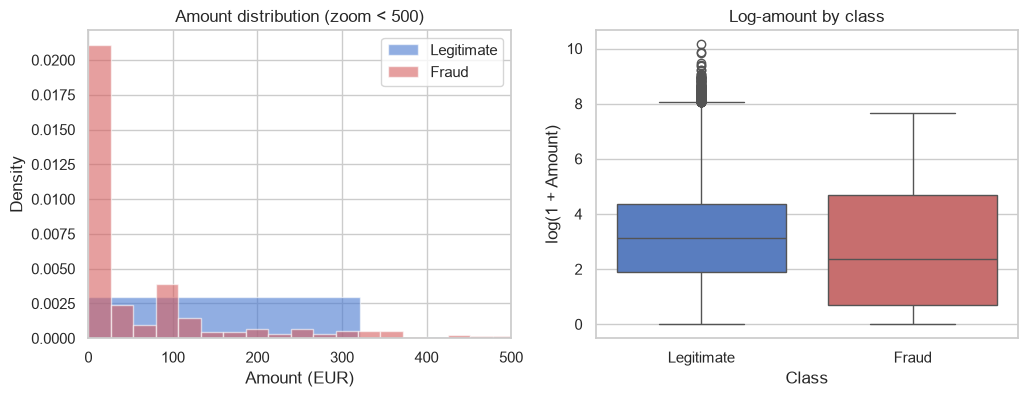

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.41,250.38,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.87,260.21,0.0,1.00,9.82,105.89,2125.87


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, name, color in [(0, "Legitimate", "#4878d0"), (1, "Fraud", "#d65f5f")]:
    axes[0].hist(df.loc[df["Class"] == label, "Amount"], bins=80,
                 alpha=0.6, label=name, color=color, density=True)
axes[0].set_xlim(0, 500)
axes[0].set_xlabel("Amount (EUR)")
axes[0].set_ylabel("Density")
axes[0].set_title("Amount distribution (zoom < 500)")
axes[0].legend()

sns.boxplot(data=df, x="Class", y=np.log1p(df["Amount"]), hue="Class",
            ax=axes[1], palette=["#4878d0", "#d65f5f"], legend=False)
axes[1].set_xticklabels(["Legitimate", "Fraud"])
axes[1].set_ylabel("log(1 + Amount)")
axes[1].set_title("Log-amount by class")

fig.savefig(config.FIGURES_DIR / "eda_amount_by_class.png", dpi=150, bbox_inches="tight")
plt.show()

df.groupby("Class")["Amount"].describe().round(2)

The literature reports that fraud concentrates at low amounts (mostly < EUR 500; Albalawi & Dardouri, 2025) — small charges are less likely to be noticed by the cardholder. The summary table above lets us confirm this on our copy of the data.

## 4. Time patterns — motivation for the concept-drift analysis

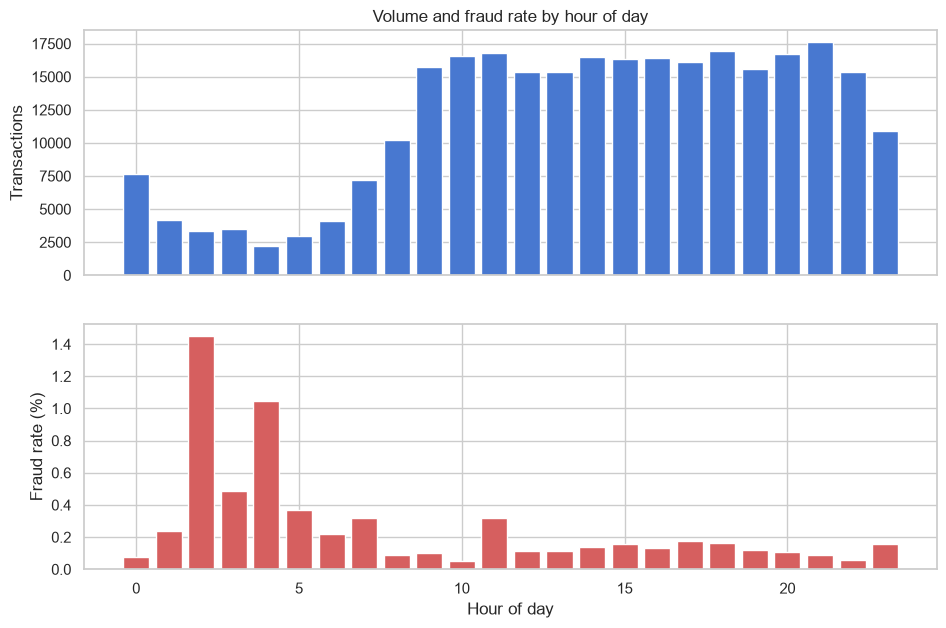

In [6]:
# Time = seconds elapsed since the first transaction; the data covers ~48h.
df["hour"] = (df["Time"] // 3600) % 24

hourly = df.groupby("hour").agg(
    n_transactions=("Class", "size"),
    n_fraud=("Class", "sum"),
)
hourly["fraud_rate"] = hourly["n_fraud"] / hourly["n_transactions"]

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].bar(hourly.index, hourly["n_transactions"], color="#4878d0")
axes[0].set_ylabel("Transactions")
axes[0].set_title("Volume and fraud rate by hour of day")
axes[1].bar(hourly.index, hourly["fraud_rate"] * 100, color="#d65f5f")
axes[1].set_ylabel("Fraud rate (%)")
axes[1].set_xlabel("Hour of day")
fig.savefig(config.FIGURES_DIR / "eda_hourly_pattern.png", dpi=150, bbox_inches="tight")
plt.show()

Fraud rate spikes in the small hours when legitimate volume is low — consistent with Afriyie et al. (2023), who found peak fraud between 22:00 and 04:00. The transaction distribution is clearly **not stationary over time**, which is exactly why Phase 4 evaluates models with chronological splits instead of random ones.

In [7]:
# How does the fraud rate differ between the two days?
df["day"] = (df["Time"] // 86400).astype(int)
df.groupby("day").agg(
    n_transactions=("Class", "size"),
    n_fraud=("Class", "sum"),
    fraud_rate=("Class", "mean"),
).style.format({"fraud_rate": "{:.4%}"})

,n_transactions,n_fraud,fraud_rate
day,,,
0,144236,272,0.1886%
1,139490,201,0.1441%


## 5. Which features discriminate fraud?

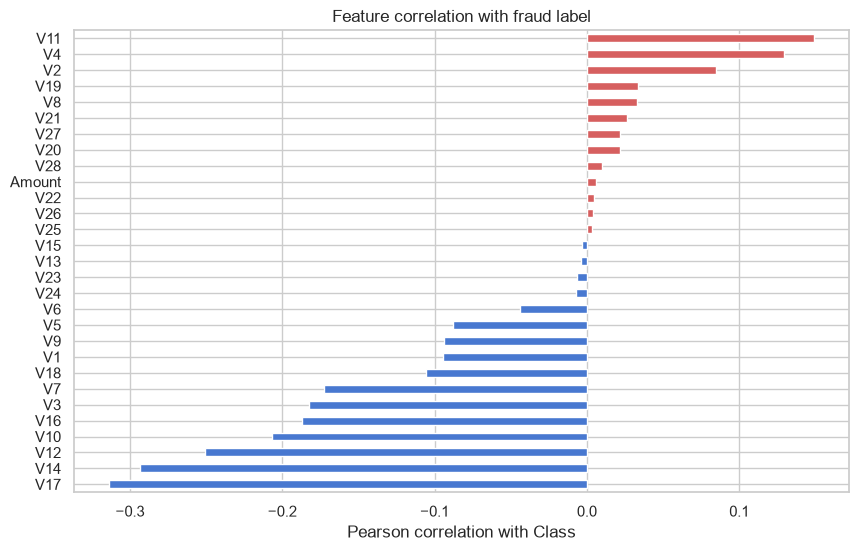

Strongest (absolute) correlations:
V17    0.313
V14    0.293
V12    0.251
V10    0.207
V16    0.187
V3     0.182
V7     0.172
V11    0.149
V4     0.129
V18    0.105
dtype: float64


In [8]:
v_cols = [f"V{i}" for i in range(1, 29)]
corr = df[v_cols + ["Amount"]].corrwith(df["Class"]).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
corr.plot.barh(ax=ax, color=np.where(corr > 0, "#d65f5f", "#4878d0"))
ax.set_xlabel("Pearson correlation with Class")
ax.set_title("Feature correlation with fraud label")
fig.savefig(config.FIGURES_DIR / "eda_feature_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

print("Strongest (absolute) correlations:")
print(corr.abs().sort_values(ascending=False).head(10).round(3))

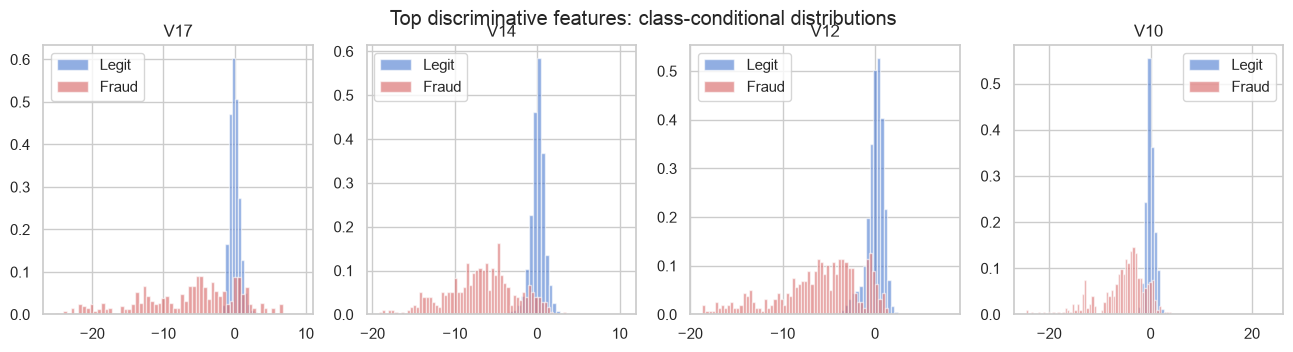

In [9]:
# Distributions of the top discriminative features
top4 = corr.abs().sort_values(ascending=False).head(4).index.tolist()
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, col in zip(axes, top4):
    for label, name, color in [(0, "Legit", "#4878d0"), (1, "Fraud", "#d65f5f")]:
        ax.hist(df.loc[df["Class"] == label, col], bins=60, alpha=0.6,
                label=name, color=color, density=True)
    ax.set_title(col)
    ax.legend()
fig.suptitle("Top discriminative features: class-conditional distributions")
fig.savefig(config.FIGURES_DIR / "eda_top_features.png", dpi=150, bbox_inches="tight")
plt.show()

Ali (SSRN working paper) reports V4, V14, V10 and V12 among the most important SHAP features — the correlation ranking above gives us an early, model-free view to compare against the Phase 5 SHAP analysis. Because V1–V28 are PCA-anonymised, business interpretation of individual features is impossible; this is an acknowledged limitation (see the portfolio's Ethical Issues section).

## 6. EDA findings (summary for the dissertation)

1. **Data quality:** no missing values; ~1,081 exact duplicate rows removed to prevent train/test contamination.
2. **Extreme imbalance:** fraud rate ≈ 0.17% — accuracy is a meaningless headline metric; PR-AUC/MCC required.
3. **Amount:** fraudulent transactions concentrate at low amounts, consistent with the literature.
4. **Time:** fraud rate varies strongly by hour (peaks overnight) and between the two days — the distribution is non-stationary, motivating chronological validation (Phase 4).
5. **Features:** V14, V17, V12, V10 (and neighbours) show the strongest class separation — a reference point for the SHAP analysis in Phase 5.
